In [1]:
# List of soil moisture datatypes
LIS_soil_moisture_datatypes = [
    664, 665, 666, 667
]

['Date', 'LIS_Soil_Moisture_0_10cm', 'LIS_Soil_Moisture_10_40cm', 'LIS_Soil_Moisture_40_100cm', 'LIS_Soil_Moisture_100_200cm']

Fetching data for LIS_Soil_Moisture_0_10cm [664]
Request submitted 
ID = c27699db-4490-4225-86dd-cccc0d113bd5
3.7%
18.3%
33.0%
44.0%
55.0%
66.0%
73.3%
88.0%
100.0%
Data retrieved successfully.
NaN values in raw_value: 0
Min value in raw_value: 0.04482172429561615
Max value in raw_value: 0.42149990797042847
Mean value in raw_value: 0.15575663873404366
Number of days: 2922

Fetching data for LIS_Soil_Moisture_10_40cm [665]
Request submitted 
ID = bfe7dfa1-f8ab-4f42-91cd-e0e6317f0e87
7.3%
14.7%
33.0%
44.0%
55.0%
62.3%
77.0%
84.3%
100.0%
Data retrieved successfully.
NaN values in raw_value: 0
Min value in raw_value: 0.03034653328359127
Max value in raw_value: 0.42149990797042847
Mean value in raw_value: 0.1505313171379773
Number of days: 2922

Fetching data for LIS_Soil_Moisture_40_100cm [666]
Request submitted 
ID = 9e96b934-c001-4685-a788-57d0c426c600
3.7%
18.3%

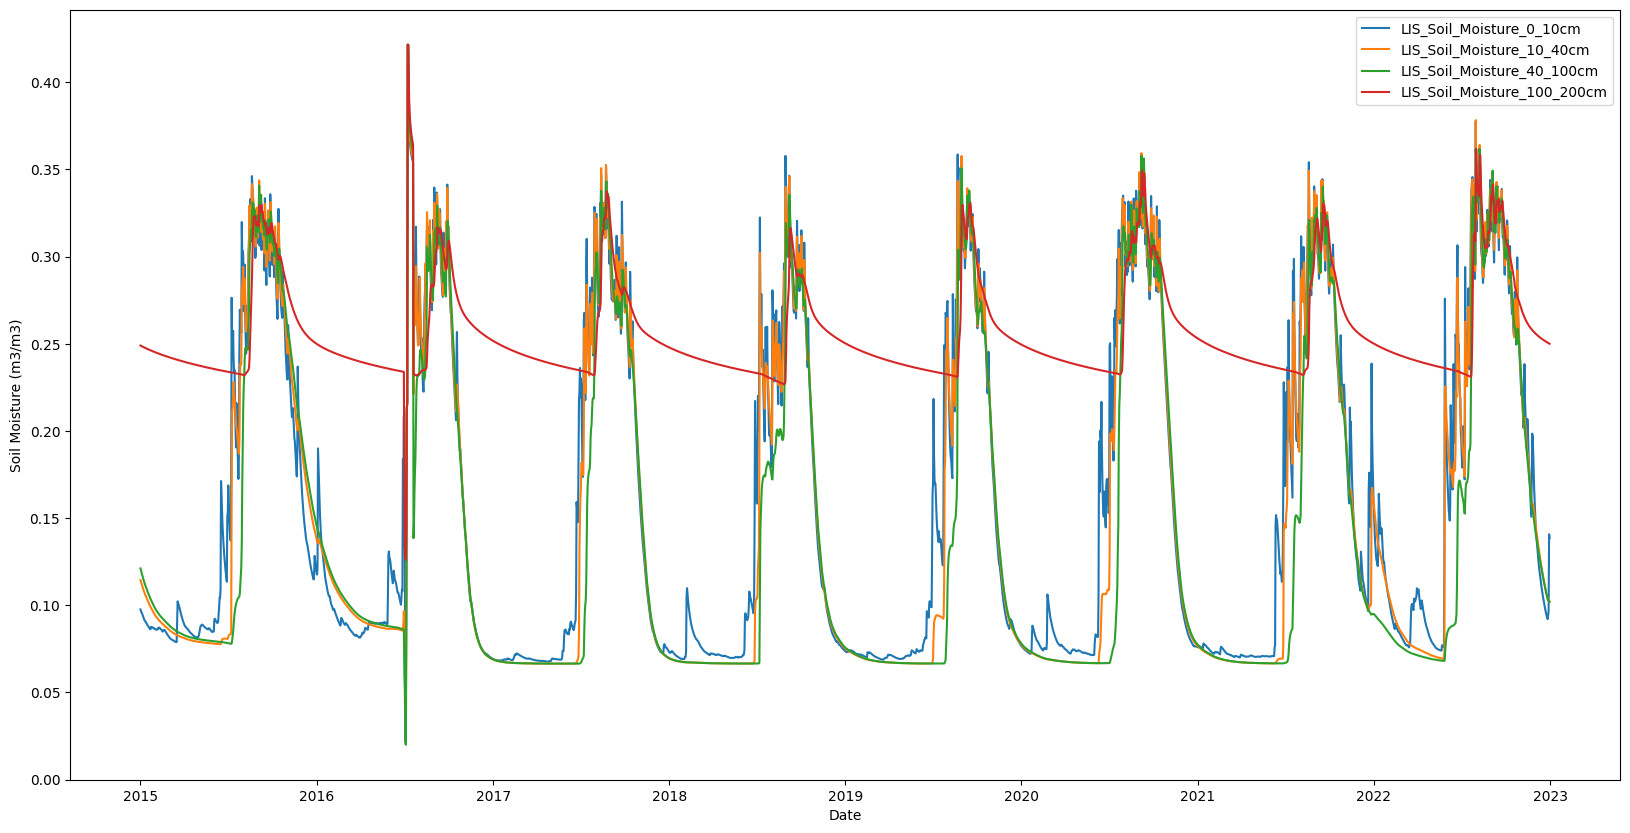

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from climateservaccess import getClimateservData, getBox, datatypeDict

def check_list(type_name): # check if the list is empty, has one value or multiple values
    type_list = df[type_name].unique().tolist()
    if len(type_list) == 0:
        return None
    elif len(type_list) == 1:
        return float(type_list[0])
    else:
        print(f"Multiple {type_name} found: {type_list}")
        return type_list

# Plot data for each datatype on the same graph
plt.figure(figsize=(20, 10))
plt.xlabel('Date')
plt.ylabel('Soil Moisture (m3/m3)')

# Create a dataframe to store data for all datatypes: a "Date" column and columns for each datatype
column_names = [datatypeDict[type_num] for type_num in LIS_soil_moisture_datatypes]
column_names.insert(0, 'Date')
print(column_names)
LIS_df = pd.DataFrame(columns=column_names)

# Loop through each datatype
for type_num in LIS_soil_moisture_datatypes:

    print(f"\nFetching data for {datatypeDict[type_num]} [{type_num}]")

    df = getClimateservData(type_num, '01/01/2015', '12/31/2022', 1, 5, getBox(13.302783, -16.65972, 0.01))

    temp_data = pd.DataFrame(df['datatype'].to_list())
        
    # Find all unique values in the column and convert to list
    datatype = check_list('datatype')
    operationtype = check_list('operationtype')
    intervaltype = check_list('intervaltype')

    # Create a dictionary with key as column name and values as list of unique values in the column
    params = {'datatype': datatype, 'operationtype': operationtype, 'intervaltype': intervaltype}

    # Select data from df
    temp_data = pd.DataFrame(df['data'].to_list())

    # Find extreme negative values and replace with NaN
    temp_data['raw_value'] = temp_data['raw_value'].apply(lambda x: float(x) if float(x) > -100 else None)
        
    # Convert date column to datetime
    temp_data['date'] = pd.to_datetime(temp_data['date'])
    
    # Print stats on raw_value
    print(f"NaN values in raw_value: {temp_data['raw_value'].isna().sum()}")
    print(f"Min value in raw_value: {temp_data['raw_value'].min()}")
    print(f"Max value in raw_value: {temp_data['raw_value'].max()}")
    print(f"Mean value in raw_value: {temp_data['raw_value'].mean()}")
    print(f"Number of days: {len(temp_data['date'].unique())}")

    # Save data to df, matching 
    LIS_df['Date'] = temp_data['date']
    LIS_df[datatypeDict[type_num]] = temp_data['raw_value']

    # Plot data and label
    plt.plot(temp_data['date'], temp_data['raw_value'], label=datatypeDict[type_num])
    plt.legend()

plt.show()

In [4]:
print(LIS_df.shape)
LIS_df.head()

(2922, 5)


,Date,LIS_Soil_Moisture_0_10cm,LIS_Soil_Moisture_10_40cm,LIS_Soil_Moisture_40_100cm,LIS_Soil_Moisture_100_200cm
0,2015-01-01,0.097590,0.114421,0.121105,0.248947
1,2015-01-02,0.096684,0.113486,0.120039,0.248800
2,2015-01-03,0.095938,0.112576,0.119003,0.248655
3,2015-01-04,0.095383,0.111654,0.117952,0.248511
4,2015-01-05,0.094838,0.110728,0.116894,0.248370


In [5]:
# Create new column for a weighted average of all datatypes

weights = [0.05, 0.15, 0.3, 0.5] # weights for each datatype

# This is right:
LIS_df['LIS_Soil_Moisture_Combined'] = 0
for i in range(len(LIS_soil_moisture_datatypes)):
    LIS_df['LIS_Soil_Moisture_Combined'] += LIS_df[datatypeDict[LIS_soil_moisture_datatypes[i]]] * weights[i]

LIS_df.head()

,Date,LIS_Soil_Moisture_0_10cm,LIS_Soil_Moisture_10_40cm,LIS_Soil_Moisture_40_100cm,LIS_Soil_Moisture_100_200cm,LIS_Soil_Moisture_Combined
0,2015-01-01,0.097590,0.114421,0.121105,0.248947,0.182847
1,2015-01-02,0.096684,0.113486,0.120039,0.248800,0.182269
2,2015-01-03,0.095938,0.112576,0.119003,0.248655,0.181712
3,2015-01-04,0.095383,0.111654,0.117952,0.248511,0.181158
4,2015-01-05,0.094838,0.110728,0.116894,0.248370,0.180604


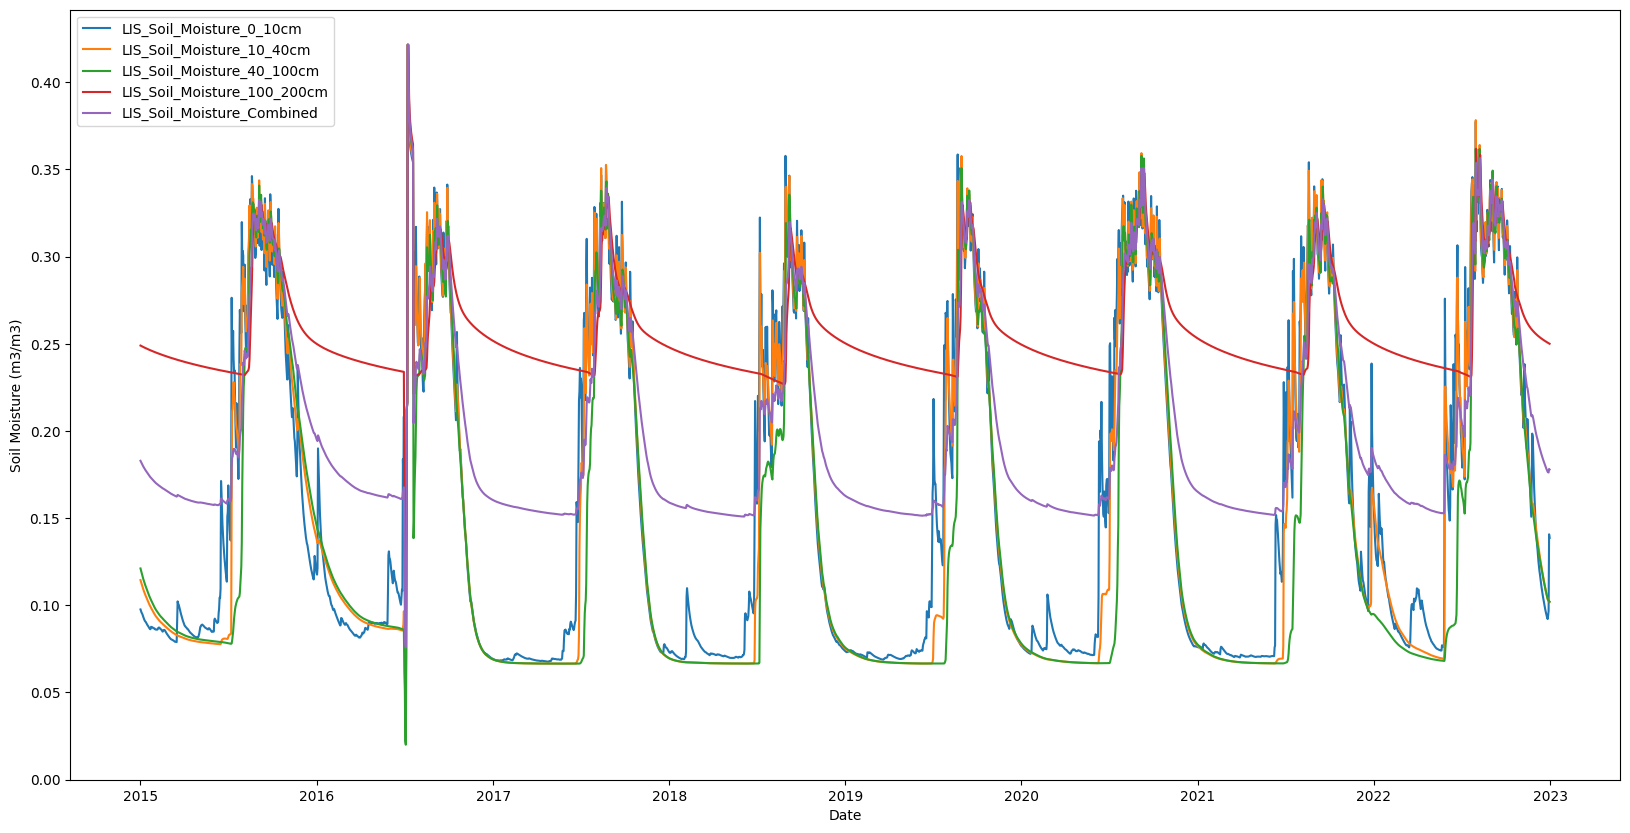

In [6]:
# Plot all columns of soil moisture data vs time
plt.figure(figsize=(20, 10))
plt.xlabel('Date')
plt.ylabel('Soil Moisture (m3/m3)')
# for each column
for col in LIS_df.columns:
    if col != 'Date':
        # plot the column
        plt.plot(LIS_df['Date'], LIS_df[col], label=col)
plt.legend()
plt.show()

In [7]:
# Save data to csv
LIS_df.to_csv('LIS_Soil_Moisture/LIS_Soil_Moisture.csv', index=False)